# 08 — Carteras 2025
Usa el mejor modelo (ventana de salida = 90 días) para construir dos carteras sobre datos de 2025:

- **Cartera 1 — Buy & Hold**: pesos iguales entre los 23 activos.
- **Cartera 2 — NN**: toma posiciones largas en activos con retorno predicho positivo y posiciones cortas en activos con retorno predicho negativo.

In [75]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import LSTM, Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, create_time_series_data, make_splits,
                   eval_mae, get_callbacks, restore_best_weights, compile_model)

## 1. Entrenamiento del mejor modelo (V_out=90)
Entrenar con todos los datos históricos hasta 2024 incluido.
Reemplazar `build_best` por la arquitectura ganadora de `06_resultados.ipynb`.

In [76]:
V_IN  = 10    # ventana de entrada del mejor modelo — ajustar según resultados
V_OUT = 90    # ventana de salida fija para carteras
EPOCHS = 300
BATCH_SIZE = 64

# Datos históricos hasta 2024
precios_hist = yf.download(TICKERS, start='1960-01-01', end='2025-01-01',
                           auto_adjust=True, progress=False)['Close']
precios_hist.dropna(axis=1, inplace=True)
returns_hist = np.log(precios_hist).diff().dropna()
print(f'Datos históricos: {returns_hist.shape}')

Datos históricos: (15857, 23)


### Modelo implementado para la construcción de la cartera NN

El modelo utilizado para generar las predicciones de retornos es una red neuronal densa sencilla, o **MLP**, aplicada sobre una ventana temporal aplanada de retornos. La entrada del modelo contiene los últimos `V_in` días de retornos de los 23 activos, transformados en un único vector de tamaño `V_in × 23`.

| Bloque | Capa | Salida esperada | Función |
|---|---|---:|---|
| Entrada | `Input((V_in * 23,))` | `V_in × 23` variables | Recibe la ventana temporal aplanada de retornos históricos |
| Capa oculta | `Dense(64, activation='relu', kernel_regularizer=l2(1e-4))` | 64 unidades | Aprende una representación no lineal de la ventana de entrada, con regularización L2 |
| Salida | `Dense(23)` | 23 valores | Predice un retorno esperado para cada uno de los 23 activos |
| Compilación | `lr=1e-4` | — | Usa una tasa de aprendizaje baja para estabilizar el entrenamiento |

La arquitectura implementada es:

```python
return compile_model(Sequential([
    Input((V_in * 23,)),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(23)
]), lr=1e-4)
```

La elección de este modelo no se debe a que haya mostrado una superioridad clara frente al resto de arquitecturas probadas. En los experimentos anteriores, los distintos modelos tendían a converger hacia valores de MAE muy similares. Esto sugiere que, ante una señal predictiva débil en los retornos, las redes terminan aprendiendo una solución muy parecida: predecir un valor central de los retornos de cada activo.

En particular, al optimizar una función de pérdida basada en MAE, el modelo tiene incentivos a aproximarse a un valor central de la distribución del objetivo. Por ello, cuando la información contenida en la ventana de entrada no permite anticipar con claridad los movimientos futuros, las predicciones tienden a parecerse mucho a la media o nivel típico de los retornos de cada activo.

Por esta razón, se selecciona esta MLP por simplicidad, interpretabilidad y preferencia personal, no porque exista evidencia clara de que sea estructuralmente mejor que las demás arquitecturas evaluadas.



MAE train=0.0013  val=0.0011  test=0.0012


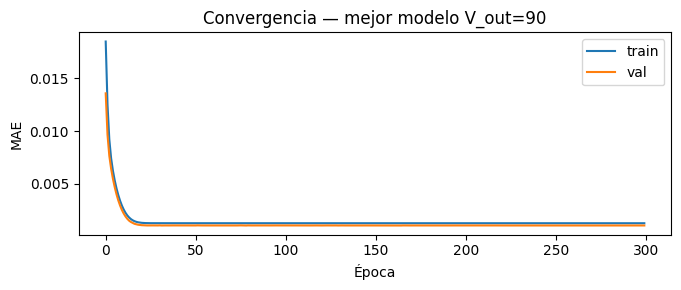

In [77]:
tf.keras.backend.clear_session()

# Modelo de referencia
def build_best(V_in):
    return compile_model(Sequential([
        Input((V_in * 23,)),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(23)
    ]), lr=1e-4)

X, y = create_time_series_data(returns_hist, V_IN, V_OUT)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

 # MLP necesita X aplanado: (N, V_in*23)
X_tr_f = X_tr.reshape(len(X_tr), -1)
X_v_f  = X_v.reshape(len(X_v),  -1)
X_ts_f = X_ts.reshape(len(X_ts), -1)

model = build_best(V_IN)

hist = model.fit(
    X_tr_f, y_tr,
    validation_data=(X_v_f, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

restore_best_weights(model)


print(f'\nMAE train={eval_mae(model, X_tr_f, y_tr):.4f}  '
      f'val={eval_mae(model, X_v_f, y_v):.4f}  '
      f'test={eval_mae(model, X_ts_f, y_ts):.4f}')

# Curva de convergencia
plt.figure(figsize=(7, 3))
plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.xlabel('Época'); plt.ylabel('MAE')
plt.title(f'Convergencia — mejor modelo V_out={V_OUT}')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Predicción de retornos para 2025

Para generar las predicciones de 2025, se utiliza el modelo ya entrenado con una ventana de entrada de `V_IN = 10` días. En el primer rebalanceo, el modelo recibe como entrada los últimos 10 días disponibles de 2024 y predice los retornos esperados para los siguientes `V_OUT = 90` días.

Al finalizar cada periodo de 90 días, se actualiza la ventana de entrada con los últimos 10 días disponibles y se solicita una nueva predicción al mismo modelo. Es importante destacar que el modelo no se vuelve a entrenar durante 2025; únicamente se reutiliza para generar nuevas predicciones con la información más reciente.

A partir de esas predicciones se construyen los pesos objetivo de la cartera NN, asignando mayor peso a los activos con mayor rentabilidad esperada.

In [84]:
# Predicciones por rebalanceo cada 90 dias

TOP_N = 23
cols = returns_hist.columns.tolist()

returns_2025 = (
    np.log(
        yf.download(
            TICKERS,
            start='2025-01-01',
            end='2026-01-01',
            auto_adjust=True,
            progress=False
        )['Close'][cols]
    )
    .diff()
    .dropna()
)

returns_all = (
    pd.concat([returns_hist[cols], returns_2025])
    .loc[lambda df: ~df.index.duplicated(keep='last')]
)

print(f'Dias de trading en 2025: {len(returns_2025)}')
print('\nPredicciones por rebalanceo cada 90 dias:\n')

rebalance_info = []

for _, periodo in returns_2025.groupby(np.arange(len(returns_2025)) // V_OUT):
    reb_date, end_date = periodo.index[[0, -1]]

    pred = pd.Series(
        model.predict(
            returns_all.loc[:reb_date].iloc[-V_IN-1:-1].to_numpy().reshape(1, -1),
            verbose=0
        ).ravel(),
        index=cols
    ).sort_values(ascending=False)

    print(f'Rebalanceo: {reb_date.date()} -> mantener hasta {end_date.date()}')
    print(f'Top {TOP_N} activos con mayor retorno predicho:')
    print('\n'.join(f'  {ticker:5s}  {value:+.5f}' for ticker, value in pred.head(TOP_N).items()))
    print('-' * 55)

    rebalance_info.extend(
        {
            'fecha_rebalanceo': reb_date,
            'fecha_fin_periodo': end_date,
            'rank': rank,
            'ticker': ticker,
            'retorno_predicho': value
        }
        for rank, (ticker, value) in enumerate(pred.items(), 1)
    )

rebalance_predictions = pd.DataFrame(rebalance_info)

Dias de trading en 2025: 249

Predicciones por rebalanceo cada 90 dias:

Rebalanceo: 2025-01-03 -> mantener hasta 2025-05-14
Top 23 activos con mayor retorno predicho:
  KR     +0.00077
  MO     +0.00071
  MSI    +0.00058
  JNJ    +0.00055
  GD     +0.00055
  KO     +0.00054
  GE     +0.00054
  MRK    +0.00053
  DIS    +0.00052
  ED     +0.00052
  CVX    +0.00051
  HON    +0.00051
  XOM    +0.00050
  BA     +0.00050
  HPQ    +0.00047
  MMM    +0.00046
  PG     +0.00045
  DTE    +0.00039
  AEP    +0.00036
  CNP    +0.00035
  CAT    +0.00035
  IBM    +0.00031
  IP     +0.00029
-------------------------------------------------------
Rebalanceo: 2025-05-15 -> mantener hasta 2025-09-23
Top 23 activos con mayor retorno predicho:
  KR     +0.00077
  MO     +0.00071
  MSI    +0.00058
  JNJ    +0.00055
  GD     +0.00055
  KO     +0.00054
  GE     +0.00054
  MRK    +0.00053
  DIS    +0.00052
  ED     +0.00052
  CVX    +0.00051
  HON    +0.00051
  XOM    +0.00050
  BA     +0.00050
  HPQ    +0.000

## 3. Construcción de carteras y Backtest
- **Buy & Hold**: pesos iguales (1/23 por activo)
- **NN**: posición larga proporcional si la predicción es positiva y posición corta proporcional si la predicción es negativa.

Normalización: suma de valores absolutos = 1 (presupuesto completo)

### Cómo funciona cada cartera

**Cartera Buy & Hold**

La cartera **Buy & Hold** se construye inicialmente de forma equiponderada entre los 23 activos. Es decir, al comienzo del periodo se asigna el mismo peso a cada activo. A partir de ese momento se aplica una estrategia estricta de *buy and hold*: se compra el primer día y no se vuelve a modificar la cartera. Por tanto, los pesos evolucionan libremente según el comportamiento relativo de cada activo.

**Cartera NN**

La cartera **NN** utiliza las predicciones generadas por el modelo. Para el primer periodo de 2025, el modelo recibe como entrada los últimos `V_IN = 10` días de 2024 y predice los retornos esperados de los siguientes 90 días.

A partir de ahí, cada 90 días se solicita una nueva predicción al modelo usando la información más reciente disponible. Con esas predicciones se actualizan los pesos objetivo de la cartera, dando más importancia a los activos con mayor rentabilidad esperada.

Además, dentro de cada bloque de 90 días, se realiza un rebalanceo cada 21 días bursátiles para reajustar la cartera hacia los pesos objetivo generados por el modelo.

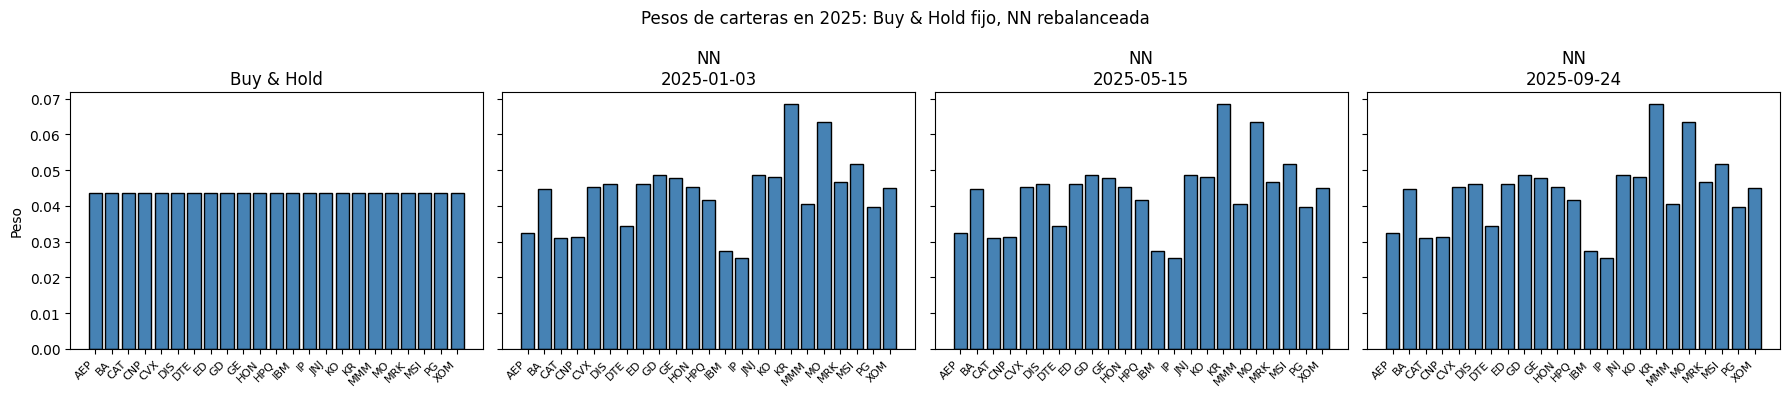

In [79]:
# Cartera 1: Buy & Hold fijo
cols = returns_hist.columns.tolist()
pesos_bh = pd.Series(1 / len(cols), index=cols, name='Buy & Hold')

# Cartera 2: NN con rebalanceo cada V_OUT dias
pesos_nn_reb = (
    rebalance_predictions
    .pivot(index='fecha_rebalanceo', columns='ticker', values='retorno_predicho')
    .reindex(columns=cols)
    .apply(lambda row: row / row.abs().sum(), axis=1)
)

# Visualizacion: Buy & Hold fijo + NN en cada rebalanceo
n_reb = len(pesos_nn_reb)
fig, axes = plt.subplots(1, n_reb + 1, figsize=(4.5 * (n_reb + 1), 4), sharey=True)
axes = np.atleast_1d(axes)

series_plot = [pesos_bh] + [pesos_nn_reb.loc[fecha] for fecha in pesos_nn_reb.index]
titulos = ['Buy & Hold'] + [f'NN\n{fecha.date()}' for fecha in pesos_nn_reb.index]

for ax, pesos, titulo in zip(axes, series_plot, titulos):
    colors = ['steelblue' if p >= 0 else 'tomato' for p in pesos]
    ax.bar(pesos.index, pesos.values, color=colors, edgecolor='k')
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

axes[0].set_ylabel('Peso')
plt.suptitle('Pesos de carteras en 2025: Buy & Hold fijo, NN rebalanceada', fontsize=12)
plt.tight_layout()
plt.show()

In [80]:
precios_2025 = yf.download(TICKERS, start='2025-01-01', end='2026-01-01', auto_adjust=True, progress=False)['Close']
# Mantener solo los activos presentes en el modelo
cols_comunes = [t for t in precios_hist.columns if t in precios_2025.columns]
precios_2025 = precios_2025[cols_comunes]
returns_2025 = np.log(precios_2025).diff().dropna()
print(f'Días de trading en 2025: {len(returns_2025)}')

Días de trading en 2025: 249


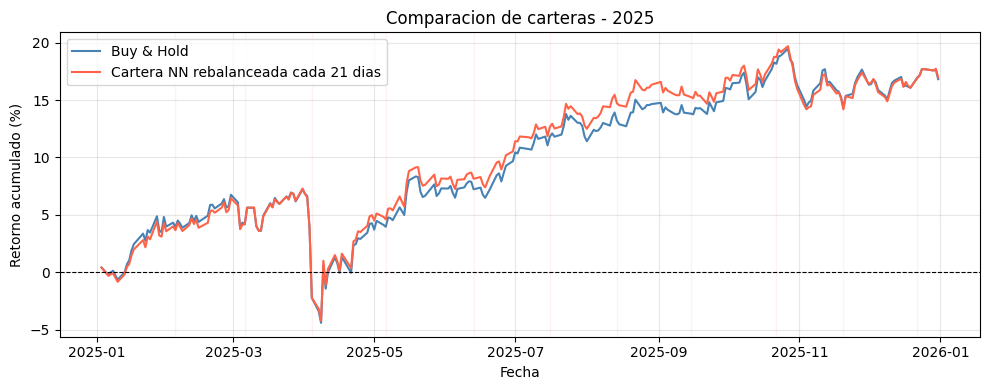

In [81]:
# returns_2025 ya esta en log-retornos
returns_eval = returns_2025[cols]

# Pesos objetivo diarios de la NN segun el modelo
objetivo_nn_diario = pd.DataFrame(index=returns_eval.index, columns=cols, dtype=float)
inicio_periodo_nn = pd.Series(index=returns_eval.index, dtype='datetime64[ns]')

periodos = (
    rebalance_predictions[['fecha_rebalanceo', 'fecha_fin_periodo']]
    .drop_duplicates()
    .sort_values('fecha_rebalanceo')
)

for reb_date, end_date in periodos.itertuples(index=False):
    idx = returns_eval.loc[reb_date:end_date].index
    objetivo_nn_diario.loc[idx] = pesos_nn_reb.loc[reb_date].values
    inicio_periodo_nn.loc[idx] = reb_date


def simular_buy_and_hold(log_returns, pesos_iniciales):
    """Buy & Hold real: se compra al inicio y luego los pesos derivan solos."""
    r_simple = np.expm1(log_returns).to_numpy()
    fechas = log_returns.index

    w = np.asarray(pesos_iniciales, dtype=float).copy()
    ret_log = np.empty(len(fechas))
    pesos_hist = pd.DataFrame(index=fechas, columns=log_returns.columns, dtype=float)

    for t, r in enumerate(r_simple):
        pesos_hist.iloc[t] = w
        rp = float(w @ r)
        ret_log[t] = np.log1p(rp)
        w = w * (1 + r) / (1 + rp)

    return ret_log, pesos_hist


def simular_nn_rebalanceo_mensual(log_returns, pesos_objetivo_diarios, inicio_periodo, rebalance_every=21):
    """
    NN:
    - cambia de pesos objetivo cuando lo indique el modelo
    - dentro de cada periodo del modelo, rebalancea cada 21 dias bursatiles
      para volver a esos pesos objetivo
    """
    r_simple = np.expm1(log_returns).to_numpy()
    fechas = log_returns.index

    ret_log = np.empty(len(fechas))
    pesos_hist = pd.DataFrame(index=fechas, columns=log_returns.columns, dtype=float)
    fechas_rebalanceo_21d = []

    objetivo_actual = None
    w = None
    periodo_actual = None
    dias_desde_rebalanceo = 0

    for t, (fecha, r) in enumerate(zip(fechas, r_simple)):
        periodo_fecha = inicio_periodo.loc[fecha]

        # Nuevo periodo del modelo: aplicar nuevos pesos objetivo
        if periodo_actual != periodo_fecha:
            periodo_actual = periodo_fecha
            objetivo_actual = pesos_objetivo_diarios.loc[fecha].to_numpy(dtype=float)
            w = objetivo_actual.copy()
            dias_desde_rebalanceo = 0

        # Pesos usados ese dia
        pesos_hist.iloc[t] = w

        # Retorno del portfolio
        rp = float(w @ r)
        ret_log[t] = np.log1p(rp)

        # Deriva natural de pesos tras el retorno del dia
        w = w * (1 + r) / (1 + rp)
        dias_desde_rebalanceo += 1

        # Rebalanceo cada 21 dias: volver a pesos objetivo del modelo
        if dias_desde_rebalanceo == rebalance_every:
            w = objetivo_actual.copy()
            fechas_rebalanceo_21d.append(fecha)
            dias_desde_rebalanceo = 0

    return ret_log, pesos_hist, fechas_rebalanceo_21d


# Cartera Buy & Hold real
ret_bh, pesos_bh_hist = simular_buy_and_hold(
    returns_eval,
    pesos_bh.loc[cols].values
)

# Cartera NN con rebalanceo cada 21 dias bursatiles
ret_nn, pesos_nn_hist, fechas_rebalanceo_21d = simular_nn_rebalanceo_mensual(
    returns_eval,
    objetivo_nn_diario,
    inicio_periodo_nn,
    rebalance_every=21
)

# Retorno acumulado
cum_bh = np.exp(np.cumsum(ret_bh)) - 1
cum_nn = np.exp(np.cumsum(ret_nn)) - 1

plt.figure(figsize=(10, 4))
plt.plot(returns_eval.index, cum_bh * 100, label='Buy & Hold', color='steelblue')
plt.plot(returns_eval.index, cum_nn * 100, label='Cartera NN rebalanceada cada 21 dias', color='tomato')

for fecha in fechas_rebalanceo_21d:
    plt.axvline(fecha, color='tomato', alpha=0.08, linewidth=1)

plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Retorno acumulado (%)')
plt.title('Comparacion de carteras - 2025')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Tabla de métricas comparativa

In [82]:
TRADING_DAYS = 252

def portfolio_metrics(daily_returns, name):
    """Calcula métricas estándar de cartera sobre retornos diarios log."""
    r = daily_returns
    ret_total      = float(np.exp(np.sum(r)) - 1)
    ret_anual      = float(np.exp(np.mean(r) * TRADING_DAYS) - 1)
    vol_anual      = float(np.std(r) * np.sqrt(TRADING_DAYS))
    sharpe         = ret_anual / vol_anual if vol_anual > 0 else np.nan
    downside       = r[r < 0]
    sortino        = ret_anual / (np.std(downside) * np.sqrt(TRADING_DAYS)) if len(downside) > 0 else np.nan
    cum            = np.exp(np.cumsum(r))
    rolling_max    = np.maximum.accumulate(cum)
    drawdown       = (cum - rolling_max) / rolling_max
    max_drawdown   = float(drawdown.min())

    return {'Retorno total (%)':      round(ret_total  * 100, 2),
            'Retorno anual (%)':      round(ret_anual  * 100, 2),
            'Volatilidad anual (%)':  round(vol_anual  * 100, 2),
            'Sharpe ratio':           round(sharpe,            3),
            'Sortino ratio':          round(sortino,           3),
            'Max Drawdown (%)':       round(max_drawdown * 100, 2)}

m_bh = portfolio_metrics(ret_bh, 'Buy & Hold')
m_nn = portfolio_metrics(ret_nn, 'Cartera NN')

df_metricas = pd.DataFrame([m_bh, m_nn], index=['Buy & Hold', 'Cartera NN']).T
print('\n── Métricas de carteras 2025 ──')
display(df_metricas)


── Métricas de carteras 2025 ──


,Buy & Hold,Cartera NN
Retorno total (%),16.820,16.960
Retorno anual (%),17.040,17.180
Volatilidad anual (%),13.220,13.260
Sharpe ratio,1.289,1.296
Sortino ratio,1.566,1.588
Max Drawdown (%),-10.850,-10.750


## 5. Conclusiones

### Una evidencia adicional de que el modelo tiende a predecir la media

In [83]:
pesos_rebalanceo = (
    rebalance_predictions
    .pivot(index='fecha_rebalanceo', columns='ticker', values='retorno_predicho')
    .apply(lambda x: x / x.abs().sum(), axis=1)
    .round(4)
)

display(pesos_rebalanceo)

ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
fecha_rebalanceo,,,,,,,,,,,,,,,,,,,,,
2025-01-03,0.0323,0.0447,0.031,0.0313,0.0453,0.0461,0.0343,0.0461,0.0486,0.0479,...,0.0254,0.0487,0.0482,0.0684,0.0406,0.0635,0.0468,0.0518,0.0397,0.0449
2025-05-15,0.0323,0.0447,0.031,0.0313,0.0453,0.0461,0.0343,0.0461,0.0486,0.0479,...,0.0254,0.0487,0.0482,0.0684,0.0406,0.0635,0.0468,0.0518,0.0397,0.0449
2025-09-24,0.0323,0.0447,0.031,0.0313,0.0453,0.0461,0.0343,0.0461,0.0486,0.0479,...,0.0254,0.0487,0.0482,0.0684,0.0406,0.0635,0.0468,0.0518,0.0397,0.0449


Como se puede observar en las predicciones que el modelo realiza cada 90 días para rebalancear la cartera, estas son prácticamente siempre iguales. Esto se debe al problema ya comentado: el modelo colapsa hacia un predictor de la media y, por ello, en las tres predicciones a 90 días estima el mismo retorno esperado.

Sin embargo, esta estrategia ha obtenido en 2025 una rentabilidad 0,140 puntos porcentuales superior a la estrategia buy and hold. Aun así, este resultado no es lo suficientemente consistente ni prolongado en el tiempo como para afirmar que se deba a la calidad predictiva del modelo. Puede deberse al azar, al periodo concreto de mercado, al efecto del rebalanceo o a la exposición distinta a ciertos activos.

Si bien es cierto que el modelo se ha basado, en la práctica, en la media histórica de cada activo, y que esto puede aportar cierta información, cabría esperar un comportamiento más sofisticado por parte de una red neuronal de estas características.